In [2]:
import sys
from pathlib import Path

import numpy as np
import cv2
import matplotlib.pyplot as plt

%matplotlib inline

# ---- Adjust this if your notebook lives elsewhere ----
PROJECT_ROOT = Path.cwd().parent if (Path.cwd().name == "NoteBooks") else Path.cwd()
GRAPH_ROOT   = PROJECT_ROOT / "superPixel_graph"

print("Project root:", PROJECT_ROOT.resolve())
print("Graph root:  ", GRAPH_ROOT.resolve())


Project root: D:\Retina SEM New
Graph root:   D:\Retina SEM New\superPixel_graph


In [3]:
from typing import Dict

SPLIT = "train"    # "train", "val", or "test"
IMAGE_INDEX = 0    # which graph file in that split

split_dir = GRAPH_ROOT / SPLIT
graph_files = sorted(split_dir.glob("*_graph.npz"))
print(f"Found {len(graph_files)} graph files in {split_dir}")

if len(graph_files) == 0:
    raise RuntimeError("No graph files found. Check Step 2 output path and SPLIT.")

graph_path = graph_files[IMAGE_INDEX]
print("Using graph file:", graph_path.name)


Found 480 graph files in d:\Retina SEM New\superPixel_graph\train
Using graph file: 100_A_graph.npz


In [4]:
# Load graph npz
data = np.load(graph_path, allow_pickle=True)

features   = data["features"]
edges      = data["edges"]
node_seeds = data["node_seeds"]
centroids  = data["centroids"]

# FIX: Always resolve image paths relative to PROJECT_ROOT
image_path = PROJECT_ROOT / Path(str(data["image_path"]))
fov_path   = PROJECT_ROOT / Path(str(data["fov_path"]))

print("Resolved image path:", image_path)
print("Resolved FOV path:  ", fov_path)

# Load grayscale image
gray_u8 = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
if gray_u8 is None:
    raise RuntimeError(f"Could not read image at {image_path}")


Resolved image path: d:\Retina SEM New\preprocessed\train\images\100_A.png
Resolved FOV path:   d:\Retina SEM New\preprocessed\train\fov_masks\100_A.png


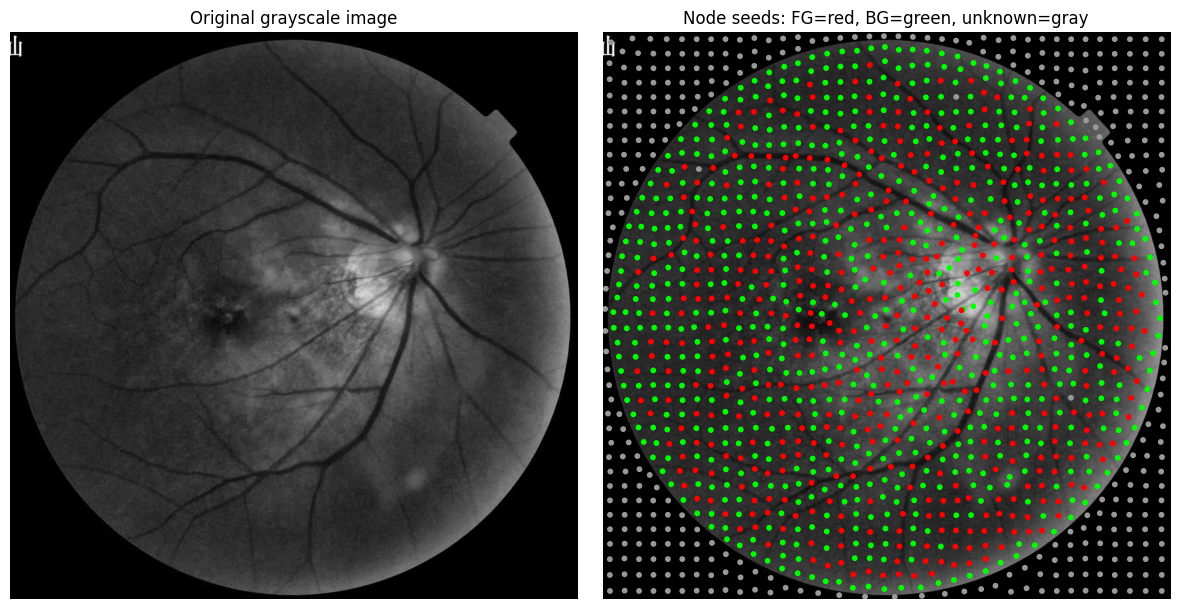

In [5]:
K = features.shape[0]
H, W = gray_u8.shape

# Colors for seeds: unknown=gray, BG=green, FG=red
colors_seed = np.zeros((K, 3), dtype=np.float32)
colors_seed[node_seeds == -1] = [0.6, 0.6, 0.6]  # unknown
colors_seed[node_seeds == 0]  = [0.0, 1.0, 0.0]  # BG
colors_seed[node_seeds == 1]  = [1.0, 0.0, 0.0]  # FG

cent_y = centroids[:, 0]
cent_x = centroids[:, 1]

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].imshow(gray_u8, cmap="gray")
axs[0].set_title("Original grayscale image")
axs[0].axis("off")

axs[1].imshow(gray_u8, cmap="gray")
axs[1].scatter(cent_x, cent_y, s=10, c=colors_seed)
axs[1].set_title("Node seeds: FG=red, BG=green, unknown=gray")
axs[1].axis("off")

plt.tight_layout()
plt.show()


In [6]:
def build_adjacency_list(num_nodes: int, edges: np.ndarray):
    """Convert edge list (2, E) into adjacency list."""
    adj = [[] for _ in range(num_nodes)]
    u = edges[0]
    v = edges[1]
    for ui, vi in zip(u, v):
        ui = int(ui)
        vi = int(vi)
        adj[ui].append(vi)
        adj[vi].append(ui)
    return adj

K = features.shape[0]
adj = build_adjacency_list(K, edges)

# Seed prior vector s in [0,1]
s = np.full(K, 0.5, dtype=np.float32)
s[node_seeds == 1] = 1.0  # FG
s[node_seeds == 0] = 0.0  # BG

# Optional: seed strength per node (FG/BG stronger than unknown)
w_seed = np.zeros(K, dtype=np.float32)
w_seed[node_seeds == 1] = 1.0  # FG
w_seed[node_seeds == 0] = 1.0  # BG
# unknown nodes: 0.0 → no direct seed force


In [7]:
def run_structural_entropy_diffusion(
    adj,
    s,
    w_seed,
    num_iters: int = 200,
    alpha: float = 0.6,    # graph smoothness weight
    beta: float = 0.3,     # seed strength
    sharpen_every: int = 20,
    sharpen_k: float = 8.0,
):
    """
    Simple structural-entropy-style graph diffusion.

    x_t+1 = (1 - alpha - beta) * x_t
            + alpha * (mean over neighbors)
            + beta  * s

    Every 'sharpen_every' steps, apply a sigmoid sharpening
    around 0.5 to push probabilities away from 0.5.
    """
    K = len(adj)

    # Initial x: seed value or 0.5 for unknown nodes
    x = s.copy()

    for it in range(num_iters):
        x_new = np.empty_like(x)

        # Graph diffusion + seed attraction
        for i in range(K):
            nbrs = adj[i]
            if nbrs:
                nbr_mean = np.mean(x[nbrs])
            else:
                nbr_mean = x[i]

            # If this node has a strong seed, enforce it more.
            gamma = beta * (w_seed[i])
            # Nodes without seeds: gamma=0, so only graph + self
            x_i = (1.0 - alpha - gamma) * x[i] + alpha * nbr_mean + gamma * s[i]
            x_new[i] = x_i

        # Clamp to [0,1]
        x_new = np.clip(x_new, 0.0, 1.0)

        # Sharpen occasionally to reduce entropy (push away from 0.5)
        if (it + 1) % sharpen_every == 0:
            x_centered = x_new - 0.5
            x_new = 1.0 / (1.0 + np.exp(-sharpen_k * x_centered))

        x = x_new

    return x


In [8]:
x_final = run_structural_entropy_diffusion(
    adj,
    s,
    w_seed,
    num_iters=300,
    alpha=0.5,
    beta=0.4,
    sharpen_every=15,
    sharpen_k=10.0,
)

print("x_final stats: min =", float(x_final.min()),
      "max =", float(x_final.max()),
      "mean =", float(x_final.mean()))

# Rough classification for visualization
fg_nodes = x_final >= 0.5
bg_nodes = x_final < 0.5
print("Approx FG nodes:", int(fg_nodes.sum()))
print("Approx BG nodes:", int(bg_nodes.sum()))


x_final stats: min = 0.007190280593931675 max = 0.986089825630188 mean = 0.3148006796836853
Approx FG nodes: 475
Approx BG nodes: 1021


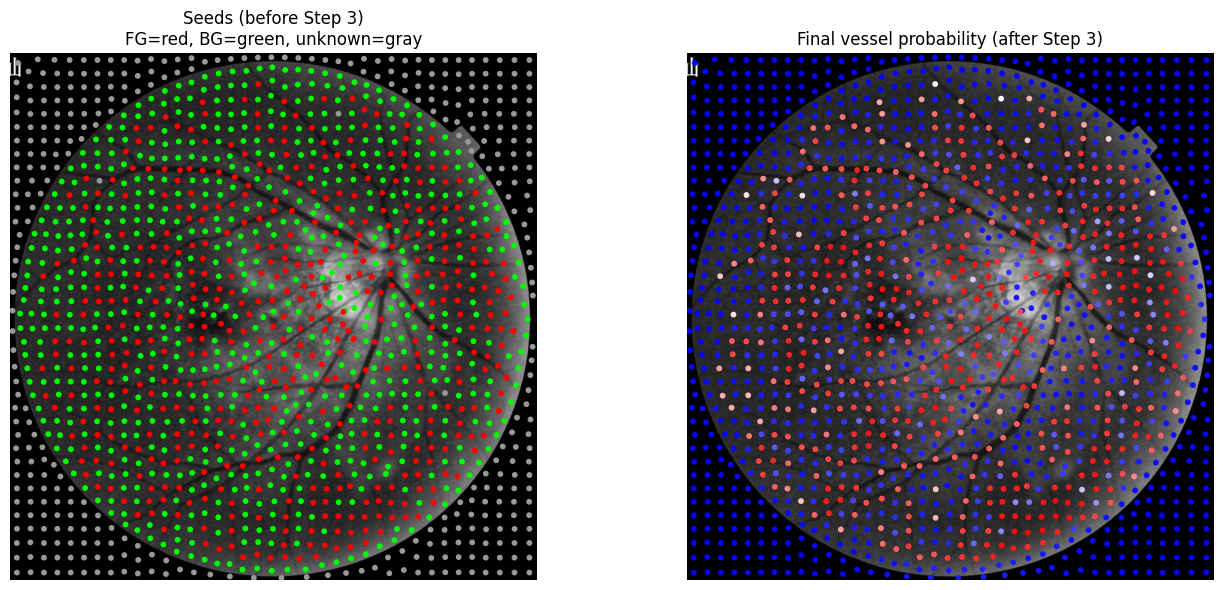

In [9]:
# Build a colormap of probabilities for nodes
# low prob (0) -> blue, mid (0.5) -> white, high (1) -> red
def prob_to_rgb(p):
    # p in [0,1]
    # simple two-color blend: blue -> white -> red
    p = float(p)
    if p <= 0.5:
        t = p / 0.5   # 0..1
        # blue (0,0,1) -> white (1,1,1)
        return np.array([t, t, 1.0])
    else:
        t = (p - 0.5) / 0.5  # 0..1
        # white (1,1,1) -> red (1,0,0)
        return np.array([1.0, 1.0 - t, 1.0 - t])

colors_prob = np.stack([prob_to_rgb(p) for p in x_final], axis=0)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: seeds
axs[0].imshow(gray_u8, cmap="gray")
axs[0].scatter(cent_x, cent_y, s=10, c=colors_seed)
axs[0].set_title("Seeds (before Step 3)\nFG=red, BG=green, unknown=gray")
axs[0].axis("off")

# Right: final probabilities
axs[1].imshow(gray_u8, cmap="gray")
axs[1].scatter(cent_x, cent_y, s=10, c=colors_prob)
axs[1].set_title("Final vessel probability (after Step 3)")
axs[1].axis("off")

plt.tight_layout()
plt.show()


In [10]:
# === SEM Cell 1: build edge weights from node features ===

# We'll use all 4 features: [mean_intensity, mean_vesselness, cy_norm, cx_norm]
F = features.astype(np.float32)          # (K, 4)
u = edges[0].astype(np.int64)            # (E,)
v = edges[1].astype(np.int64)            # (E,)

# Squared feature distance for each edge
diff = F[u] - F[v]                       # (E, 4)
dist2 = np.sum(diff ** 2, axis=1)        # (E,)

# Scale parameter for similarity (use median distance for robustness)
sigma2 = np.median(dist2) + 1e-6

# Edge weights: higher when features are similar
w_e = np.exp(-dist2 / sigma2).astype(np.float32)   # (E,)

print("Edge weights stats: min =", float(w_e.min()),
      "max =", float(w_e.max()), "median =", float(np.median(w_e)))


Edge weights stats: min = 0.0 max = 0.7295141220092773 median = 0.3681657910346985


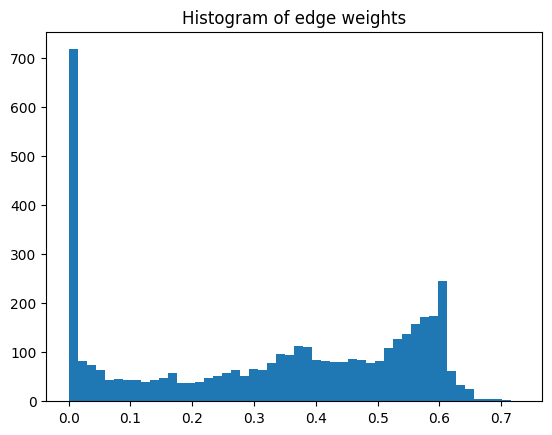

In [14]:
plt.hist(w_e, bins=50)
plt.title("Histogram of edge weights")
plt.show()


In [21]:
# === SEM Cell 2 (REPLACE OLD ONE): stable SEM optimizer ===

def run_sem_optimization_stable(
    s,
    w_seed,
    edges,
    w_e,
    num_iters: int = 300,
    lr: float = 0.01,
    lam_seed: float = 3.0,
    lam_smooth: float = 2.0,
    lam_ent: float = 0.1,
):
    """
    Stable structural-entropy-inspired optimization on node probabilities x in [0,1].

    J(x) = lam_seed  * sum_i w_seed[i] * (x_i - s_i)^2
         + lam_smooth* sum_(i,j) w_e * (x_i - x_j)^2
         + lam_ent   * sum_i H(x_i),  H(x) = -x log x - (1-x) log(1-x)

    Uses gradient descent with:
      - per-iteration clipping of x into (0,1)
      - gradient normalization to avoid exploding steps
    """
    K = s.shape[0]
    x = s.copy().astype(np.float32)
    eps = 1e-4

    u = edges[0].astype(np.int64)
    v = edges[1].astype(np.int64)
    w_e = w_e.astype(np.float32)

    for it in range(num_iters):
        # keep probabilities inside (0,1) to avoid log(0)
        x = np.clip(x, eps, 1.0 - eps)

        grad = np.zeros_like(x, dtype=np.float32)

        # --- seed fidelity term ---
        # lam_seed * sum_i w_seed[i] (x_i - s_i)^2
        grad += 2.0 * lam_seed * w_seed * (x - s)

        # --- graph smoothness term ---
        # lam_smooth * sum_e w_e (x_i - x_j)^2
        diff = x[u] - x[v]                    # (E,)
        contrib = 2.0 * lam_smooth * w_e * diff
        np.add.at(grad, u, contrib)
        np.add.at(grad, v, -contrib)

        # --- entropy term ---
        # H(x) = -x log x - (1-x) log(1-x)
        # dH/dx = -log(x/(1-x))
        ent_grad = -np.log(x / (1.0 - x))
        grad += lam_ent * ent_grad

        # ---- gradient normalization for stability ----
        g_max = float(np.max(np.abs(grad)))
        if g_max > 0:
            grad = grad / (g_max + 1e-6)

        # gradient descent step
        x -= lr * grad

        if (it + 1) % 50 == 0:
            print(f"[iter {it+1}] x: min={float(x.min()):.4f}, "
                  f"max={float(x.max()):.4f}, mean={float(x.mean()):.4f}")

    return np.clip(x, 0.0, 1.0)

In [28]:
# === SEM Cell 3 (REPLACE OLD ONE): run stable SEM ===

x_sem = run_sem_optimization_stable(
    s=s,
    w_seed=w_seed,
    edges=edges,
    w_e=w_e,
    num_iters=300,
    lr=0.01,
    lam_seed=2.0,
    lam_smooth=3.0,
    lam_ent=0.05,
)

print("SEM x stats: min =", float(x_sem.min()),
      "max =", float(x_sem.max()),
      "mean =", float(x_sem.mean()))

fg_nodes_sem = x_sem >= 0.6
bg_nodes_sem = x_sem < 0.6
print("SEM approx FG nodes:", int(fg_nodes_sem.sum()))
print("SEM approx BG nodes:", int(bg_nodes_sem.sum()))


[iter 50] x: min=-0.0007, max=1.0007, mean=0.4386
[iter 100] x: min=-0.0099, max=1.0099, mean=0.4350
[iter 150] x: min=-0.0099, max=1.0099, mean=0.4342
[iter 200] x: min=-0.0099, max=1.0099, mean=0.4341
[iter 250] x: min=-0.0099, max=1.0099, mean=0.4341
[iter 300] x: min=-0.0099, max=1.0099, mean=0.4341
SEM x stats: min = 0.0 max = 1.0 mean = 0.4343179166316986
SEM approx FG nodes: 328
SEM approx BG nodes: 1168


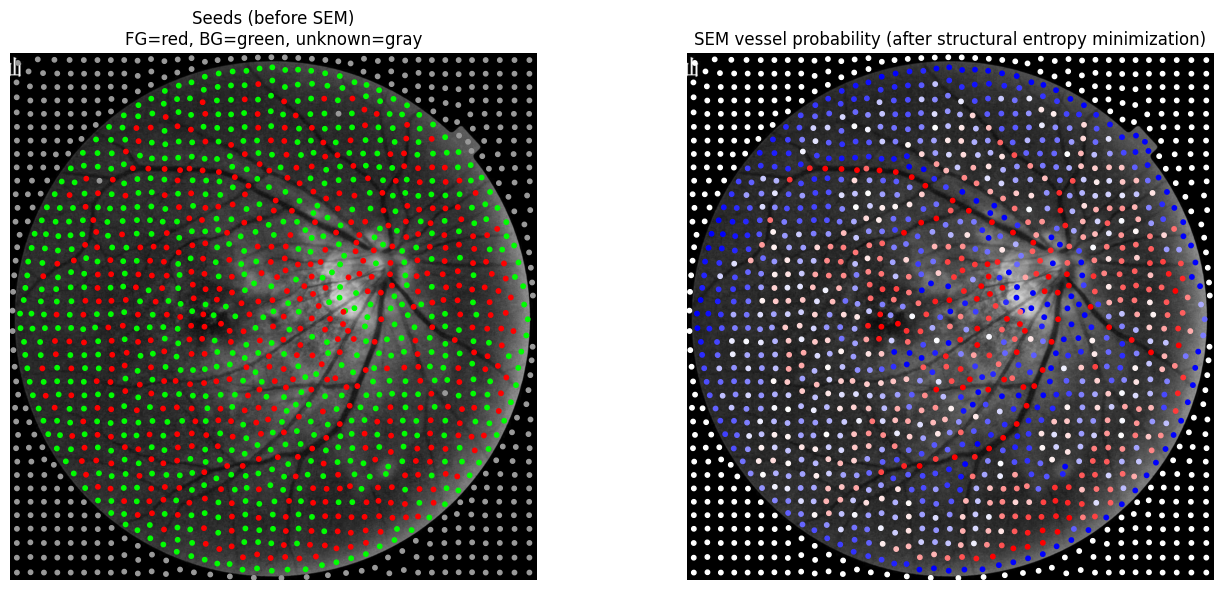

In [29]:
# === SEM Cell 4: visualize SEM result on the graph ===

def prob_to_rgb_sem(p):
    # p in [0,1] → blue (0) --> white (0.5) --> red (1)
    p = float(p)
    if p <= 0.5:
        t = p / 0.5
        return np.array([t, t, 1.0])          # blue -> white
    else:
        t = (p - 0.5) / 0.5
        return np.array([1.0, 1.0 - t, 1.0 - t])  # white -> red

colors_sem = np.stack([prob_to_rgb_sem(p) for p in x_sem], axis=0)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Left: seeds (same as before)
axs[0].imshow(gray_u8, cmap="gray")
axs[0].scatter(centroids[:, 1], centroids[:, 0], s=10, c=colors_seed)
axs[0].set_title("Seeds (before SEM)\nFG=red, BG=green, unknown=gray")
axs[0].axis("off")

# Right: SEM probabilities
axs[1].imshow(gray_u8, cmap="gray")
axs[1].scatter(centroids[:, 1], centroids[:, 0], s=10, c=colors_sem)
axs[1].set_title("SEM vessel probability (after structural entropy minimization)")
axs[1].axis("off")

plt.tight_layout()
plt.show()
